<a href="https://colab.research.google.com/github/Datchanapriya/E-Commerce-analysis/blob/main/E_commerce_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import zipfile

zip_path = '/content/archive (2).zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print(f"'{zip_path}' extracted to '/content/'")

'/content/archive (2).zip' extracted to '/content/'


In [ ]:
import os

print(os.listdir('/content/'))

['.config', 'archive (2).zip', 'synthetic_online_retail_data.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv('/content/synthetic_online_retail_data.csv', encoding='latin1')

In [ ]:
print(df.head())
print(df.info())

   customer_id  order_date  product_id  category_id       category_name  \
0        13542  2024-12-17         784           10         Electronics   
1        23188  2024-06-01         682           50   Sports & Outdoors   
2        55098  2025-02-04         684           50   Sports & Outdoors   
3        65208  2024-10-28         204           40  Books & Stationery   
4        63872  2024-05-10         202           20             Fashion   

  product_name  quantity   price payment_method            city  review_score  \
0   Smartphone         2  373.36    Credit Card  New Oliviaberg           1.0   
1  Soccer Ball         5  299.34    Credit Card    Port Matthew           NaN   
2         Tent         5   23.00    Credit Card      West Sarah           5.0   
3   Story Book         2  230.11  Bank Transfer  Hernandezburgh           5.0   
4        Skirt         4  176.72    Credit Card    Jenkinshaven           1.0   

  gender  age  
0      F   56  
1      M   59  
2      F   64 

In [ ]:
print(df.isnull().sum())

customer_id         0
order_date          0
product_id          0
category_id         0
category_name       0
product_name        0
quantity            0
price               0
payment_method      0
city                0
review_score      201
gender            103
age                 0
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
# Extract time-based features from 'order_date'
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_day_of_week'] = df['order_date'].dt.dayofweek
df['order_hour'] = df['order_date'].dt.hour

print(df[['order_date', 'order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_hour']].head())

  order_date  order_year  order_month  order_day  order_day_of_week  \
0 2024-12-17        2024           12         17                  1   
2 2025-02-04        2025            2          4                  1   
3 2024-10-28        2024           10         28                  0   
4 2024-05-10        2024            5         10                  4   
5 2024-12-03        2024           12          3                  1   

   order_hour  
0           0  
2           0  
3           0  
4           0  
5           0  


In [ ]:
df = df[df['quantity'] > 0]

In [ ]:
df['TotalPrice'] = df['quantity'] * df['price']
print(df[['quantity', 'price', 'TotalPrice']].head())

   quantity   price  TotalPrice
0         2  373.36      746.72
2         5   23.00      115.00
3         2  230.11      460.22
4         4  176.72      706.88
5         4  196.16      784.64


In [ ]:
df = df[df['price'] > 0]

In [ ]:
df['TotalPrice'] = df['quantity'] * df['price']

In [ ]:
df.to_csv('/content/cleaned_online_retail.csv', index=False)

print("Cleaning Completed")

Cleaning Completed


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/cleaned_online_retail.csv')

In [ ]:
print(df.head())
print(df.info())

   customer_id  order_date  product_id  category_id       category_name  \
0        13542  2024-12-17         784           10         Electronics   
1        55098  2025-02-04         684           50   Sports & Outdoors   
2        65208  2024-10-28         204           40  Books & Stationery   
3        63872  2024-05-10         202           20             Fashion   
4        29989  2024-12-03         829           10         Electronics   

  product_name  quantity   price payment_method            city  review_score  \
0   Smartphone         2  373.36    Credit Card  New Oliviaberg           1.0   
1         Tent         5   23.00    Credit Card      West Sarah           5.0   
2   Story Book         2  230.11  Bank Transfer  Hernandezburgh           5.0   
3        Skirt         4  176.72    Credit Card    Jenkinshaven           1.0   
4   Smartphone         4  196.16  Bank Transfer  East Tonyaberg           5.0   

  gender  age  order_year  order_month  order_day  order_day_o

In [ ]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)

product_name
Laptop         113
T-shirt        112
Smartphone     112
Yoga Mat        98
Soccer Ball     96
Pants           95
Blanket         93
Headphones      89
Tablet          88
Vase            87
Name: quantity, dtype: int64


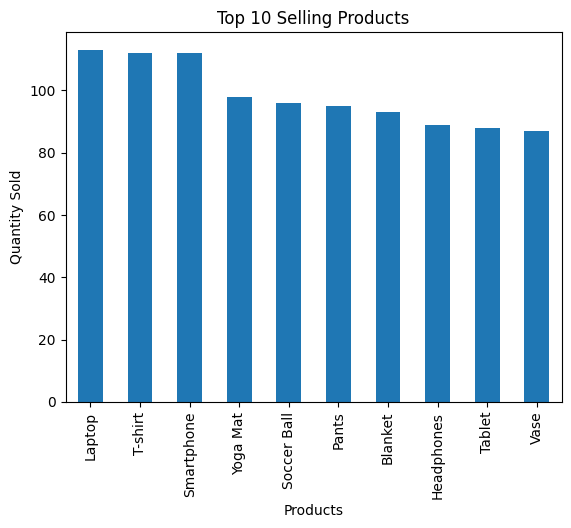

In [ ]:
top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=90)
plt.show()

In [ ]:
top_revenue = df.groupby('product_name')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(top_revenue)

product_name
Laptop         28765.94
Yoga Mat       27554.01
Smartphone     26912.37
Notebook       26606.45
Tablet         25760.69
Soccer Ball    25391.47
T-shirt        24561.56
Headphones     23771.30
Smartwatch     23696.82
Pants          23116.51
Name: TotalPrice, dtype: float64


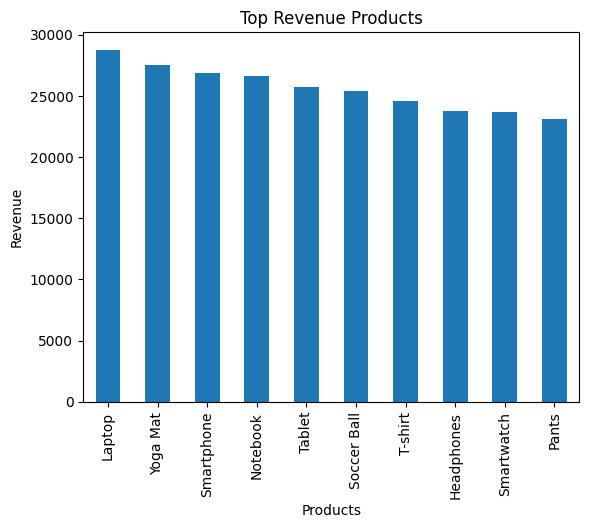

In [ ]:
top_revenue.plot(kind='bar')
plt.title('Top Revenue Products')
plt.xlabel('Products')
plt.ylabel('Revenue')

plt.xticks(rotation=90)
plt.show()

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
df['Month'] = df['order_date'].dt.month

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
print(monthly_sales)

Month
1     42786.45
2     37648.01
3     41048.44
4     33611.80
5     49227.32
6     37757.20
7     43046.15
8     57070.83
9     54183.34
10    42624.25
11    38806.44
12    57497.48
Name: TotalPrice, dtype: float64


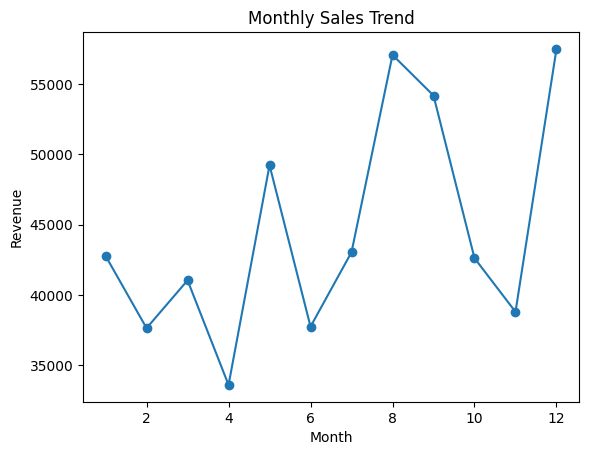

In [ ]:
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

In [ ]:
country_sales = df.groupby('city')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(country_sales)

city
Port Melissaborough    3941.29
Brownbury              2603.16
South Elizabeth        2581.12
Jenniferville          2434.50
Port Paul              2382.65
Melanieborough         2379.45
South Roger            2376.55
Frazierbury            2352.15
West Antonio           2351.00
South Elizabethport    2342.75
Name: TotalPrice, dtype: float64


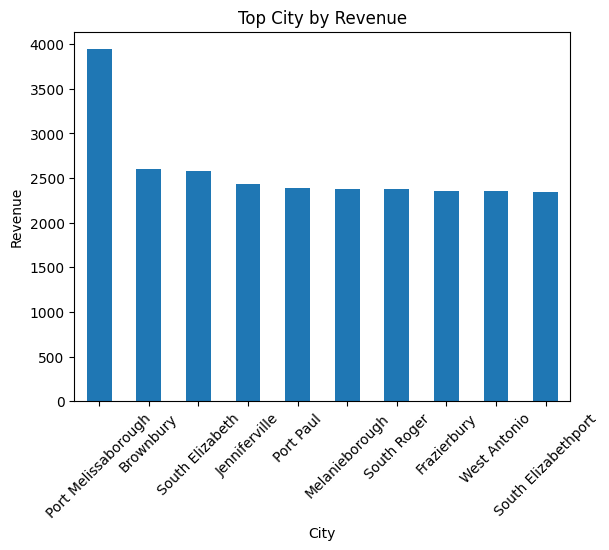

In [ ]:
country_sales.plot(kind='bar')

plt.title('Top City by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')

plt.xticks(rotation=45)
plt.show()

In [ ]:
top_customers = df.groupby('customer_id')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print(top_customers)

customer_id
41613    2437.65
42739    2434.50
61358    2382.65
83687    2379.45
59486    2378.10
77823    2376.55
24175    2352.15
99026    2351.00
20393    2342.75
27462    2331.90
Name: TotalPrice, dtype: float64


In [ ]:
average_order = df['TotalPrice'].mean()

print("Average Order Value:", average_order)

Average Order Value: 742.4517475728155


In [ ]:
frequent_products = df['product_name'].value_counts().head(10)

print(frequent_products)

product_name
Smartphone     35
Yoga Mat       35
Pants          35
Laptop         33
Blanket        33
T-shirt        33
Soccer Ball    32
Eraser         31
Headphones     31
Smartwatch     29
Name: count, dtype: int64
